In [4]:
# testrun = "false"
testrun = "true"

In [5]:
print(testrun)

true


# Evaluate with GPT-4

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import pickle


In [8]:
import re
import openai
import pandas as pd
import random


import sys
import os
import tiktoken
from tenacity import (
    retry,
    stop_after_attempt,
    wait_random_exponential,
)  # for exponential backoff

In [9]:
from brush_llm_funcs import brush_prepost_prob_llm, brush_get_probs_from_llm, brush_get_llm_responses

In [5]:
%load_ext dotenv
%dotenv /vast/palmer/home.mccleary/vs428/Documents/DischargeMe/hail-dischargeme/.env

In [15]:
def num_tokens_from_string(string: str, encoding_name: str="cl100k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [16]:
from IPython.display import display, HTML

def add_line_breaks(text):
    return text.replace('\n', '<br>')


def pretty_print(df):
    return display( HTML( df.to_html().replace("\\n","<br>") ) )

In [17]:
data = pd.read_csv("all_cases.csv", sep="|",  engine="c")

In [18]:
data['case'] = data['case'].str.replace("“", '"')
data['case'] = data['case'].str.replace("”", '"')
data['case'] = data['case'].str.replace("’", "'")
data['case'] = data['case'].str.replace("½", "1/2")
data['case'] = data['case'].str.replace("–", "-")

In [19]:
for case in data['case'].tolist():
    try:
        case.encode('ascii')
    except UnicodeDecodeError:
        print("it was not a ascii-encoded unicode string")

In [66]:
with pd.option_context("display.max_colwidth", 2000):
    # display(data.sample(5))
    display(data)

,index,case_id,case_type,probability,differential,case,lab_value_text,q1,q2,pos_lr,neg_lr
0,0,1,ACS,low,most likely anxiety,"A 28 year-old woman presents to the ED with a 3 day history of chest pain. She has been under considerable stress lately related to marital problems. He works as a secretary and has had problems concentrating at work. She feels anxious and is having problems sleeping at night. For 3 days, she has experienced a vague tightness in her chest that seems to be provoked by anxiety. The tightness will last up to an hour and usually resolves when she is able to calm herself down. She remains fairly active and does not experience chest discomfort with exertion. She had chest pain at work and a co-worker insisted that she have it checked out. She is currently complaining of mild tightness in the mid chest without radiation.\n\nPMH is remarkable only for anxiety and borderline hypertension, which is untreated.\n\nOn examination, HR=100, BP=140/90, RR=20. She appears anxious in mild distress. Lungs are clear to auscultation and her cardiac exam is normal.","A troponin level was drawn and reported back from the lab as [normal or abnormal]. Studies show that troponin testing in this setting has a sensitivity of 95%, specificity of 80% and a positive likelihood ratio of 4.75 and a negative likelihood ratio of 0.25.",What is the probability that this patient has an acute myocardial infarction?,Now what is the probability that this patient has an acute myocardial infarction?,4.75,0.25
1,1,2,ACS,low,most likely pericarditis,"A 35 year-old man presents to the ED with a 3-day history of chest pain. About a week ago, he had an upper respiratory illness, with a sore throat, non-productive cough, and a fever as high as 101 degrees (F). He saw his primary care physician and was prescribed ampicillin and Tylenol. His symptoms improved after about 3-4 days. Several days ago, he began experiencing chest pain described as a sharp pain in the left chest without radiation. The pain would occur several times daily without any particular precipitating factor. The pain seemed to worsen when he took a deep breath. He has noted mild shortness of breath because he has found it hard to take a deep breath.\n\nPMH is unremarkable. He is otherwise healthy and takes no medicaitons.\n\nOn examination, HR-100, BO=120/80, RR=24. He is in mild distress due to pain. HEENT is unremarkable. There is mild cervical adenopathy. Lungs are clear to auscultation. Cardiac exam reveal a regular rate and rhythm and a short mid-systolic sound that may be a murmur or a rub. There is no chest tenderness and the abdominal exam is benign.","A troponin level was drawn and reported back from the lab as [normal or abnormal]. Studies show that troponin testing in this setting has a sensitivity of 95%, specificity of 80% and a positive likelihood ratio of 4.75 and a negative likelihood ratio of 0.25.",What is the probability that this patient has an acute myocardial infarction?,Now what is the probability that this patient has an acute myocardial infarction?,4.75,0.25
2,2,3,ACS,low,most likely GERD,"A 50 year-old woman presents to the ED with a weeklong history of chest pain. She is otherwise healthy and quite active. Over the past week, she has notices a burning in her mid chest without radiation. This will occur during the day and usually resolves after she has something to eat. She will also experience the pain at night after she goes to bed. She will usually fall asleep and she has noticed that the pain is usually gone when she awakens in the morning. She had a prolonged episode of pain this evening and her husband insisted that she get this checked out. He called 911 and she was brought in by ambulance. She is having mild pain on arrival in the ED.\n\nPMH is remarkable for a history of hypertension, for which she takes a diuretic.\n\nOn examination, she is comfortable. HR=90, BP=130/85, RR=16. Lungs are clear and cardiac exam reveals a regular rate and rhythm and n

# Qualitative Evaluation

In [ ]:
import pickle
with open("neg_chat_histories.pickle", "rb") as f:
    neg_chat_histories = pickle.load(f)

In [ ]:
import pickle
with open("pos_chat_histories.pickle", "rb") as f:
    pos_chat_histories = pickle.load(f)

In [63]:
print("\n------------------------------------\n------------------------------------\n".join([message.content for message in pos_chat_histories[30].messages]))

A 29-year-old woman presents complaining of chest heaviness.  For the past three days she has complained of sinus congestion, a sore throat and a dry non-productive cough.  She is worried that she might have caught something from her roommate, who has also been sick for the past few days.  However, her inability to catch her breath is the reason that she is attending the emergency department. She denies any pleuritic chest pain or calf swelling.  She was able to exercise yesterday without feeling short of breath. However, she kept coughing, so she gave up when people at the gym kept giving her a dirty look. 

The patient is well without any other medical problems. She is a non-smoker.   Her only medication is ibuprofen, which she has been taking for the last 3 days to address her sore throat and because "her body feels achy and run down."  

On examination, her temperature is 37.3C; pulse 76 / minute; blood pressure 110/76mmHg; and respiratory rate 18 / minute. Her heart rate is regula

In [ ]:
print(data.iloc[27]['lab_value_text'])

# Redo Pre-test and Post-test probs from ChatHistory

## Negative Labs

In [95]:
neg_chat_histories = pickle.load(open("neg_chat_histories.pickle", "rb"))

In [96]:
neg_pretest_probs, neg_posttest_probs = brush_get_probs_from_llm(neg_chat_histories)

In [127]:
# neg_pretest_probs

In [128]:
# neg_posttest_probs

In [99]:
neg_pretest_responses, neg_posttest_responses = brush_get_llm_responses(neg_chat_histories)

In [100]:
neg_probs_df = pd.DataFrame({"pretest_prob":neg_pretest_probs, "posttest_prob":neg_posttest_probs})

In [101]:
neg_response_df = pd.DataFrame({"pretest_llm_output":neg_pretest_responses, "posttest_llm_output":neg_posttest_responses})

In [102]:
neg_data_with_gpt = pd.concat([data, neg_probs_df, neg_response_df],axis=1)

In [103]:
# neg_data_with_gpt.to_csv("all_cases_neg_gpt4_output.csv", index=False)

## Positive Labs

In [104]:
pos_chat_histories = pickle.load(open("pos_chat_histories.pickle", "rb"))

In [105]:
pos_pretest_probs, pos_posttest_probs = brush_get_probs_from_llm(pos_chat_histories)

In [106]:
pos_pretest_responses, pos_posttest_responses = brush_get_llm_responses(pos_chat_histories)

In [129]:
# pos_pretest_probs

In [130]:
# pos_posttest_probs

In [109]:
pos_probs_df = pd.DataFrame({"pretest_prob":pos_pretest_probs, "posttest_prob":pos_posttest_probs})

In [110]:
pos_response_df = pd.DataFrame({"pretest_llm_output": pos_pretest_responses, "posttest_llm_output": pos_posttest_responses})

In [111]:
pos_data_with_gpt = pd.concat([data, pos_probs_df, pos_response_df],axis=1)

In [112]:
# pos_data_with_gpt.to_csv("all_cases_pos_gpt4_output.csv", index=False)

## Re-compute Bayesian Change Score

In [113]:
def compute_true_bayesian_update(pre_test, lr):
    odds = ((pre_test)/(1-pre_test)) * lr
    post_test = odds / (1 + odds)
    return post_test
    

In [114]:
# drop the Pulmonary Embolism test cases from the positive lab df, since they have hard coded "negative" d-dimer values
pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['probability'] == "low")
& (pos_data_with_gpt['case_type'] == "Pulmonary Embolism"))]

In [115]:
# drop the respsective pneumonia cases (either positive or negative), since these were also hard-coded xray interpretations and not filled in
pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "URI")
                                        & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

pos_data_with_gpt = pos_data_with_gpt[~((pos_data_with_gpt['differential'] == "PCP v ILI")
                                        & (pos_data_with_gpt['case_type'] == "PNEUMONIA"))]

neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "Asthma Exacerbation v CAP")
                                        & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]

neg_data_with_gpt = neg_data_with_gpt[~((neg_data_with_gpt['differential'] == "HCAP")
                                        & (neg_data_with_gpt['case_type'] == "PNEUMONIA"))]

# negative: URI
# negative: PCP v ILI
# positive: Asthma Exacerbation v CAP
# positive: HCAP

In [116]:
pos_data_with_gpt['true_posttest'] = pos_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['pos_lr']) * 100, axis=1)
neg_data_with_gpt['true_posttest'] = neg_data_with_gpt.apply(lambda row: compute_true_bayesian_update(row['pretest_prob']/100, row['neg_lr']) * 100, axis=1)

In [117]:
pos_data_with_gpt['positive'] = True
neg_data_with_gpt['positive'] = False

In [118]:
data_with_gpt = pd.concat([pos_data_with_gpt, neg_data_with_gpt], axis=0)

In [119]:
data_with_gpt['bayes_diff'] = data_with_gpt['true_posttest'] - data_with_gpt['posttest_prob']

In [120]:
# data_with_gpt.to_csv("all_cases_posneg_gpt4_output.csv", index=False)

# Plot

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
# results = pd.DataFrame([(neg_data_with_gpt['true_posttest'] - neg_data_with_gpt['posttest_prob']).tolist(), 
#                         (pos_data_with_gpt['true_posttest'] - pos_data_with_gpt['posttest_prob']).tolist()]).T.rename({0:"negative test", 1:"positive test"}, axis=1)

In [123]:
data_with_gpt['bayes_diff'].describe()

count    78.000000
mean      0.303100
std       1.247518
min      -0.448276
25%      -0.023232
50%       0.016431
75%       0.118577
max       8.724138
Name: bayes_diff, dtype: float64

In [124]:
data_with_gpt[data_with_gpt['positive'] == True]['bayes_diff'].describe()

count    37.000000
mean      0.258363
std       1.473677
min      -0.448276
25%      -0.036681
50%       0.000000
75%       0.058824
max       8.724138
Name: bayes_diff, dtype: float64

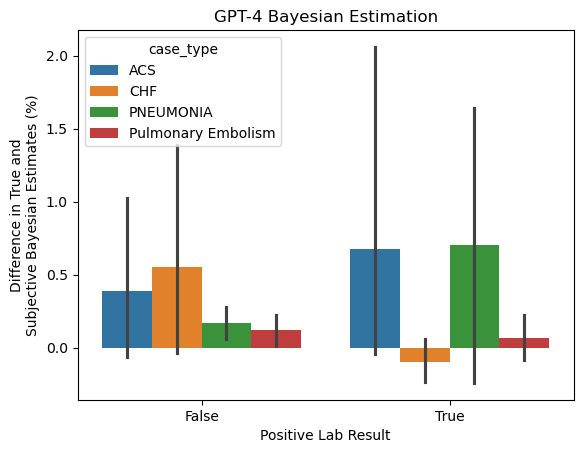

In [139]:
fig = sns.barplot(data_with_gpt, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.title("GPT-4 Bayesian Estimation")
plt.savefig("difference_by_condition.png", bbox_inches="tight")

# Scratch: Evaluate No Explicit Bayes' Rule Results

In [2]:
import pandas as pd

In [3]:
nobayes_output = pd.read_csv("all_cases_posneg_gpt4_output_1no_reasoning.csv")

In [4]:
nobayes_output

,index,case_id,case_type,probability,differential,case,lab_value_text,q1,q2,pos_lr,neg_lr,pretest_prob,posttest_prob,pretest_llm_output,posttest_llm_output,true_posttest,positive,bayes_diff
0,0,1,ACS,low,most likely anxiety,A 28 year-old woman presents to the ED with a ...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,5.0,70.0,The likelihood of acute myocardial infarction ...,The likelihood of acute myocardial infarction ...,20.000000,True,-50.000000
1,1,2,ACS,low,most likely pericarditis,A 35 year-old man presents to the ED with a 3-...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,5.0,70.0,The likelihood of acute myocardial infarction ...,The likelihood of acute myocardial infarction ...,20.000000,True,-50.000000
2,2,3,ACS,low,most likely GERD,A 50 year-old woman presents to the ED with a ...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,5.0,70.0,The likelihood of acute myocardial infarction ...,The likelihood of acute myocardial infarction ...,20.000000,True,-50.000000
3,3,4,ACS,low,likely musculoskeletal,A 50 year-old man presents to the ED with ches...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,5.0,70.0,The likelihood of acute myocardial infarction ...,The likelihood of acute myocardial infarction ...,20.000000,True,-50.000000
4,4,5,ACS,medium,ACS versus hypertensive emergency,A 50 year-old woman presents to the ED with ch...,A troponin level was drawn and reported back f...,What is the probability that this patient has ...,Now what is the probability that this patient ...,4.75,0.25,70.0,91.0,The likelihood of acute myocardial infarction ...,The likelihood of acute myocardial infarction ...,91.724138,True,0.724138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,38,9,Pulmonary Embolism,medium,PE v Anxiety,A 33 year old man presents complaining of retr...,A quantitative D-dimer is measured. The value...,What is the probability that this patient has ...,What is the probability that this patient has ...,1.70,0.09,30.0,5.0,The likelihood of pulmonary embolism is 30%.,The likelihood of pulmonary embolism is 5%.,3.713893,False,-1.286107
74,39,10,Pulmonary Embolism,high,PE,An 86 year old women presents from home post s...,A quantitative D-dimer is measured. The value...,What is the probability that this patient has ...,What is the probability that this patient has ...,1.70,0.09,70.0,15.0,The likelihood of pulmonary embolism is 70%.,The likelihood of pulmonary embolism is 15%.,17.355372,False,2.355372
75,40,11,Pulmonary Embolism,high,PE,A 29 yo female presents complaining of pleurit...,A quantitative D-dimer is measured. The value...,What is the probability that this patient has ...,What is the probability that this patient has ...,1.70,0.09,85.0,15.0,The likelihood of pulmonary embolism is 85%.,The likelihood of pulmonary embolism is 15%.,33.774834,False,18.774834
76,41,12,Pulmonary Embolism,high,PE,A 54 year old man presents with shortness of b...,A quantitative D-dimer is measured. The value...,What is the probability that this patient has ...,What is the probability that this patient has ...,1.70,0.09,85.0,15.0,The likelihood of pulmonary embolism is 85%.,The likelihood of pulmonary embolism is 15%.,33.774834,False,18.774834
